We'll redo atmo_box_test.py to test if it works properly

In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo
#import pyrtlib as rtl
import time

import atmo3 as a3

In [2]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 128]
box_length = [20000., 20000., 10000.]

boresight  = jnp.array([box_length[0]//2., box_length[1]//2.])
passband   = {'nu': jnp.array([150.]), 'g(nu)': jnp.array([1.])}
fwhm       = 10.

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 9, 16, 0, 0, tzinfo=timezone.utc)

t0 = time.perf_counter()
# =============================================================================
# Scan strategy
# =============================================================================

# dt = 0 case
timesamples = [np.datetime64(time_utc)]
az          = [0.]      # in deg
el          = [45.]     # in deg

# remaining 300 samples
for sample in range(300-1):
    timesamples.append(timesamples[-1] + np.timedelta64(200, 'ms'))
    az.append(az[-1] + 0.2)
    el.append(el[-1]) 
    
t1 = time.perf_counter()

print(f"Scan setup time : {t1 - t0:.6f} s")

Scan setup time : 0.001110 s


/tmp/ipykernel_152653/2186992929.py:29: UserWarning: no explicit representation of timezones available for np.datetime64
  timesamples = [np.datetime64(time_utc)]


In [3]:
# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for September 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

northwindfile = f'{atmo3_data}era5/2023/v.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # V-component North wind
eastwindfile  = f'{atmo3_data}era5/2023/u.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # U-component East wind

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

t0 = time.perf_counter()
# =============================================================================
# Initialise the atmosphere object
# ERA5 profiles are read and interpolated to the site location; profiles are
# then normalised so that the ground-level temperature and column-integrated
# PWV match the mean APEX observations recorded within ±30 min of time_utc.
# =============================================================================
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)

t1 = time.perf_counter()
print(f"Atmosphere class init : {t1 - t0:.6f} s")

obs = a3.Observer(
    grid_wsp = atmo_box.grid_wsp,
    super_grid = atmo_box.super_grid,
    northwind_era5_file = None,
    eastwind_era5_file = None,
    boresight = jnp.array(boresight),       # in grid coordinates
    passband = passband, 
    fwhm_arcmin = fwhm
)

obs.compute_los_for_scan(timesamples, az, el)

t2 = time.perf_counter()
print(f"Observer init LoS compute time : {t1 - t0:.6f} s")

obs_w = a3.Observer(
    grid_wsp = atmo_box.grid_wsp,
    super_grid = atmo_box.super_grid,
    northwind_era5_file = northwindfile,
    eastwind_era5_file = eastwindfile,
    boresight = jnp.array(boresight),       # in grid coordinates
    passband = passband, 
    fwhm_arcmin = fwhm
)

obs_w.compute_los_for_scan(timesamples, az, el)

1.1099999999999999 0.0607453701939497
Atmosphere class init : 24.969201 s
Observer init LoS compute time : 24.969201 s


In [5]:
k_array = np.arange(4*nside_grid[0]) * jnp.min(atmo_box.grid_wsp.dk)

k0_q  = 2*np.pi / q_injection_scale_in_m   # Water-vapour injection wavenumber (rad/m)
k0_ta = 2*np.pi / ta_injection_scale_in_m  # Temperature injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)
pofk_ta = ( k0_ta**2. + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)

# Pack into dictionaries expected by add_temperature / add_watervapor.
pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}

atmo_box.add_temperature(
    power_spec=pspec_ta
)
t1 = time.perf_counter()
print(f"Temperature box init: {t1 - t0:.6f} s")
# Water-vapour mass-density fluctuation field (units: kg/m³).
# Scaling profile: 0.1 % of ERA5 specific-humidity mean × q→ρ conversion.
atmo_box.add_watervapor(
    power_spec=pspec_q
)
t2 =time.perf_counter()
print(f"Water box init : {t2 - t1:.6f} s")

t0 = time.perf_counter()
atmo_box.generate_realization(time_step=0)
t1 = time.perf_counter()
print(f"Generate realization : {t1 - t0:.6f} s")

Temperature box init: 71.561667 s
Water box init : 0.001150 s
Random field : 11.002270 s
Apply P(k) : 10.406635 s
IRFFT : 0.040592 s
Rescaled field : 0.474173 s
Random field : 10.329521 s
Apply P(k) : 13.060107 s
IRFFT : 0.068123 s
Rescaled field : 0.247830 s
Generate realization : 47.013375 s


Scanning time : 0.102749 s


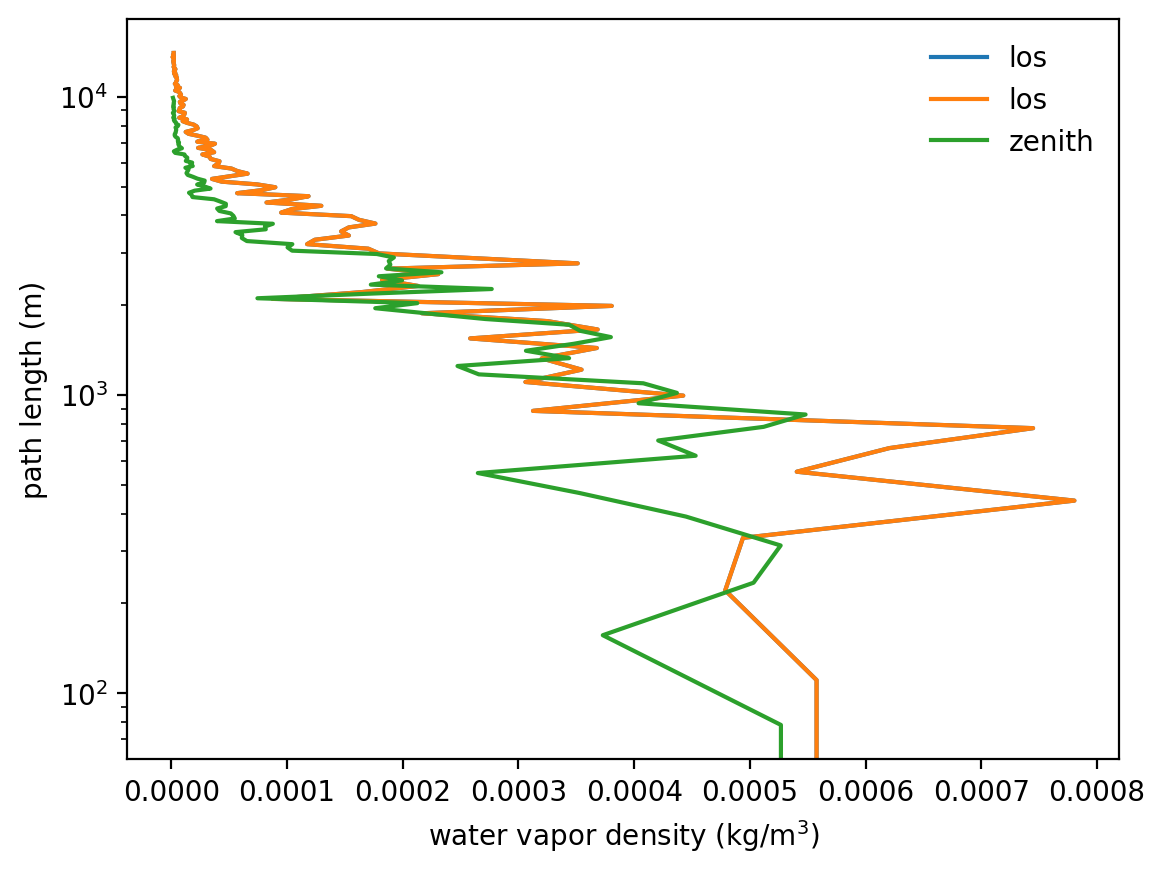

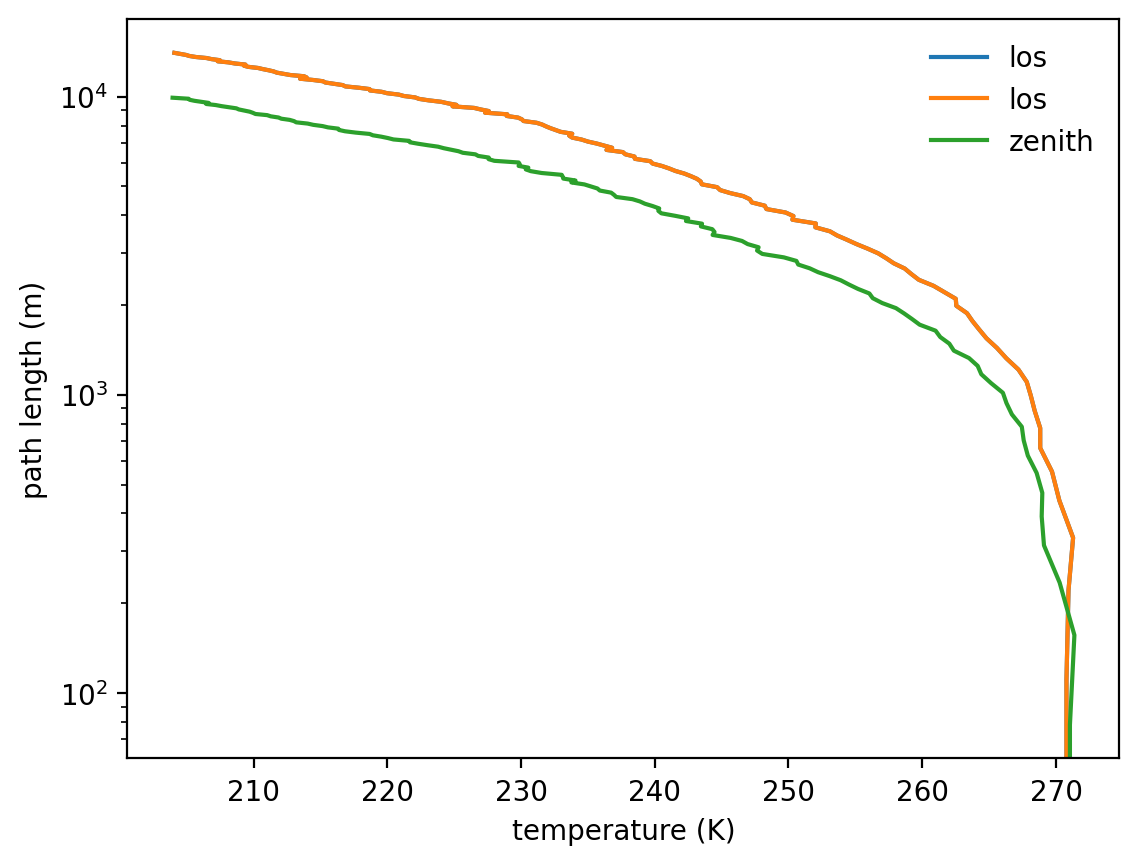

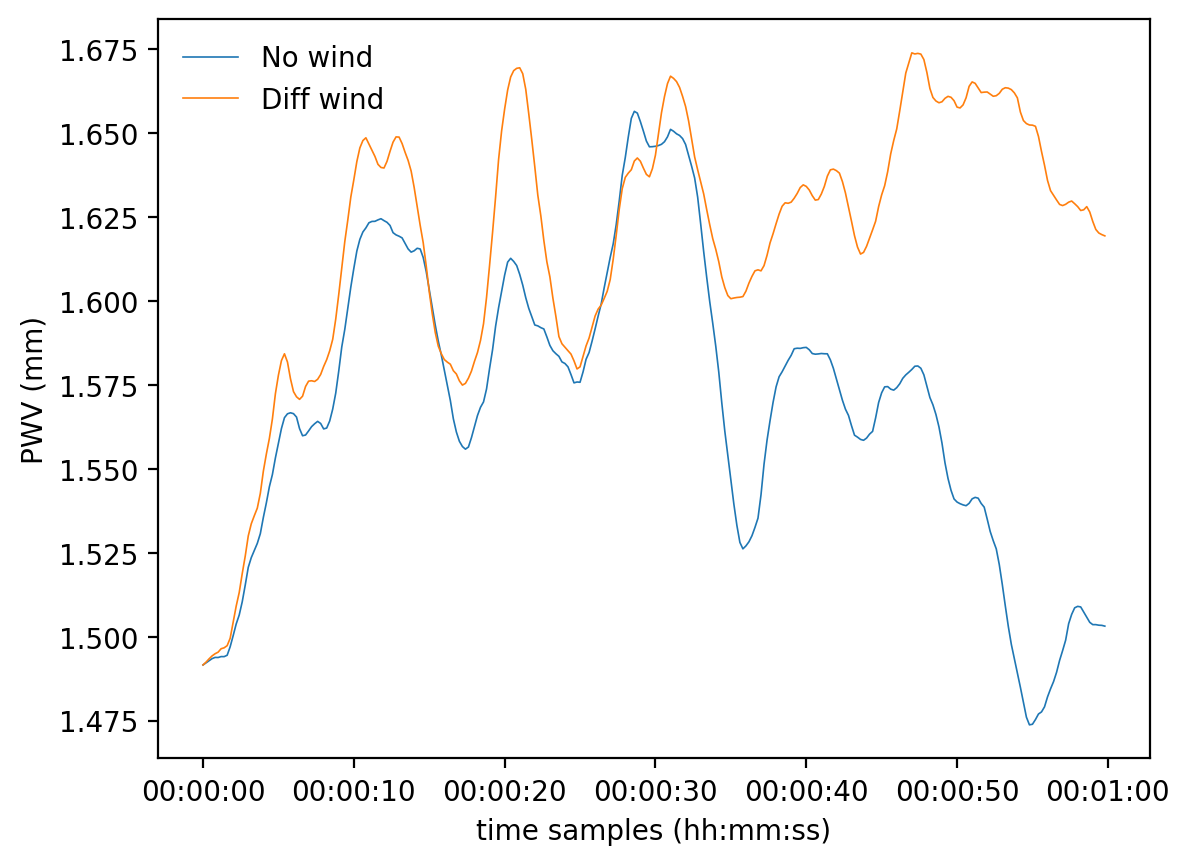

In [10]:

t0 = time.perf_counter()
water_vapor_los = obs.scan_component(atmo_box.components['water vapor'].field + atmo_box.component_mean['water vapor']['f'].reshape(1, 1, -1))
t1 = time.perf_counter()
print(f"Scanning time : {t1 - t0:.6f} s")

temperature_los = obs.scan_component(atmo_box.components['temperature'].field + atmo_box.component_mean['temperature']['f'].reshape(1, 1, -1))

water_vapor_los_w = obs_w.scan_component(atmo_box.components['water vapor'].field + atmo_box.component_mean['water vapor']['f'].reshape(1, 1, -1))
temperature_los_w = obs_w.scan_component(atmo_box.components['temperature'].field + atmo_box.component_mean['temperature']['f'].reshape(1, 1, -1))

pwv_scan   = jnp.trapezoid(water_vapor_los,   x=obs.los_obj[:,:,3], axis=1)
pwv_scan_w = jnp.trapezoid(water_vapor_los_w, x=obs.los_obj[:,:,3], axis=1)

plt.figure(dpi=200)
plt.plot(water_vapor_los[0], obs.los_obj[0,:,3], label='los')
plt.plot(water_vapor_los[0], obs_w.los_obj[0,:,3], label='los')
plt.plot((atmo_box.components['water vapor'].field + atmo_box.component_mean['water vapor']['f'].reshape(1, 1, -1))[nside_grid[0]//2, nside_grid[1]//2], atmo_box.grid_wsp.grid_axis(axis=2), label='zenith')
plt.yscale('log')
plt.xlabel(r"water vapor density (kg/m${}^3$)")
plt.ylabel("path length (m)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(temperature_los[0], obs.los_obj[0,:,3], label='los')
plt.plot(temperature_los_w[0], obs_w.los_obj[0,:,3], label='los')
plt.plot((atmo_box.components['temperature'].field + atmo_box.component_mean['temperature']['f'].reshape(1, 1, -1))[nside_grid[0]//2, nside_grid[1]//2], atmo_box.grid_wsp.grid_axis(axis=2), label='zenith')
plt.yscale('log')
plt.xlabel(r"temperature (K)")
plt.ylabel("path length (m)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(timesamples, pwv_scan,   '-', lw=0.6, label='No wind')
plt.plot(timesamples, pwv_scan_w, '-', lw=0.6, label='Diff wind')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel("PWV (mm)")
plt.legend(frameon=False)
plt.show()
plt.close()

In [38]:
pressure_los = jnp.interp(obs.los_obj[:,:,2], obs.axes[2], atmo_box.atm_calibrator.pressure) 
pressure_los_w = jnp.interp(obs_w.los_obj[:,:,2], obs_w.axes[2], atmo_box.atm_calibrator.pressure)
freqs_GHz = jnp.array([ 185., 150.])

I_atm = a3.get_emission(temperature_los, pressure_los, water_vapor_los, jnp.diff(obs.los_obj[:,:,3], axis=1, prepend=0), freqs_GHz)
T_atm = a3.intensitySI_to_Tb(I_atm[:,:,None], freqs_GHz[None, None,:])[:,:,0]

I_atm_w = a3.get_emission(temperature_los_w, pressure_los, water_vapor_los_w, jnp.diff(obs_w.los_obj[:,:,3], axis=1, prepend=0), freqs_GHz)
T_atm_w = a3.intensitySI_to_Tb(I_atm_w[:,:,None], freqs_GHz[None, None,:])[:,:,0]



In [37]:
print(T_atm.shape)

(300, 1)


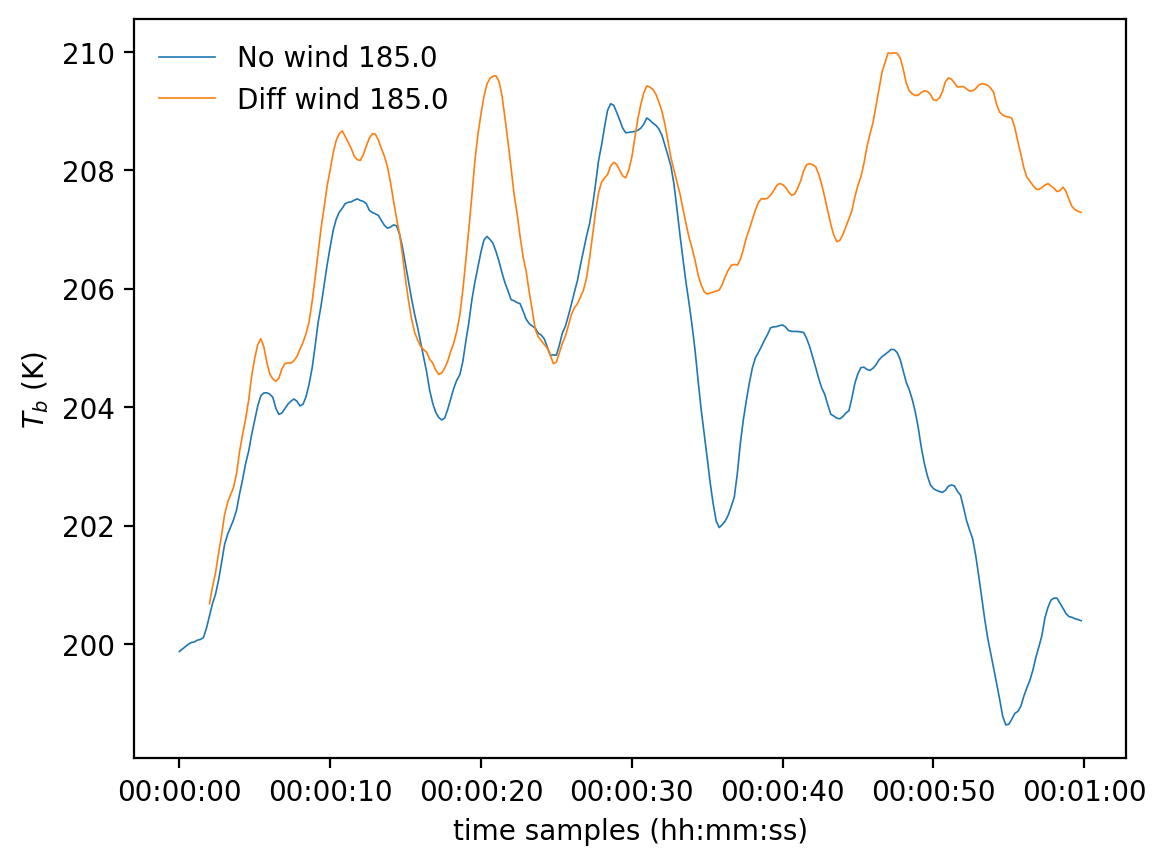

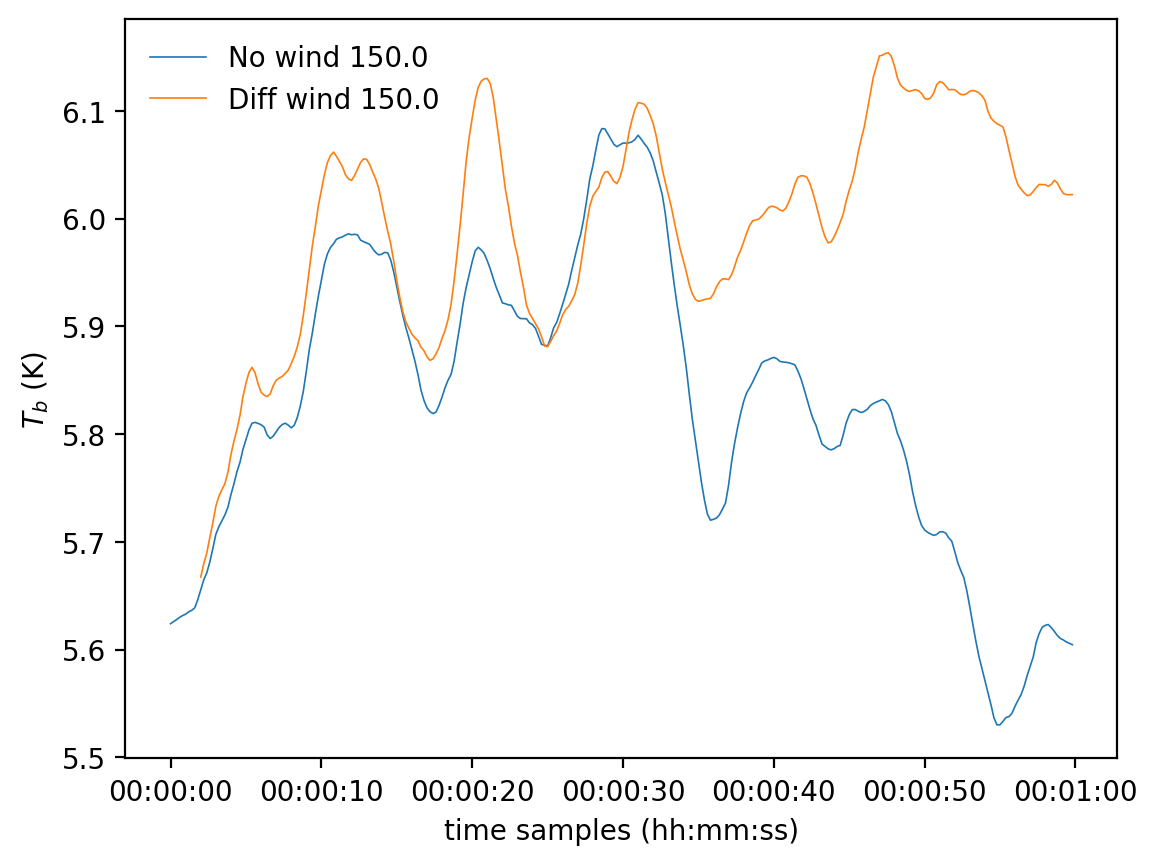

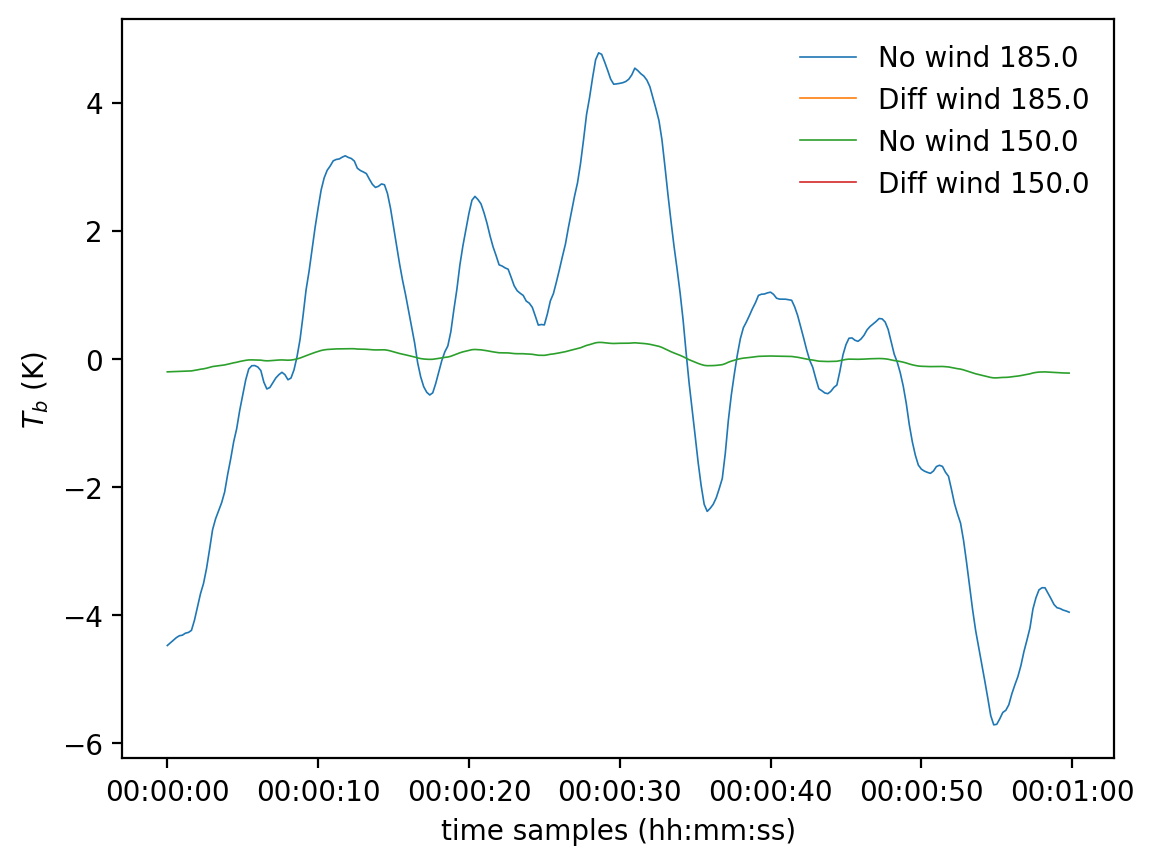

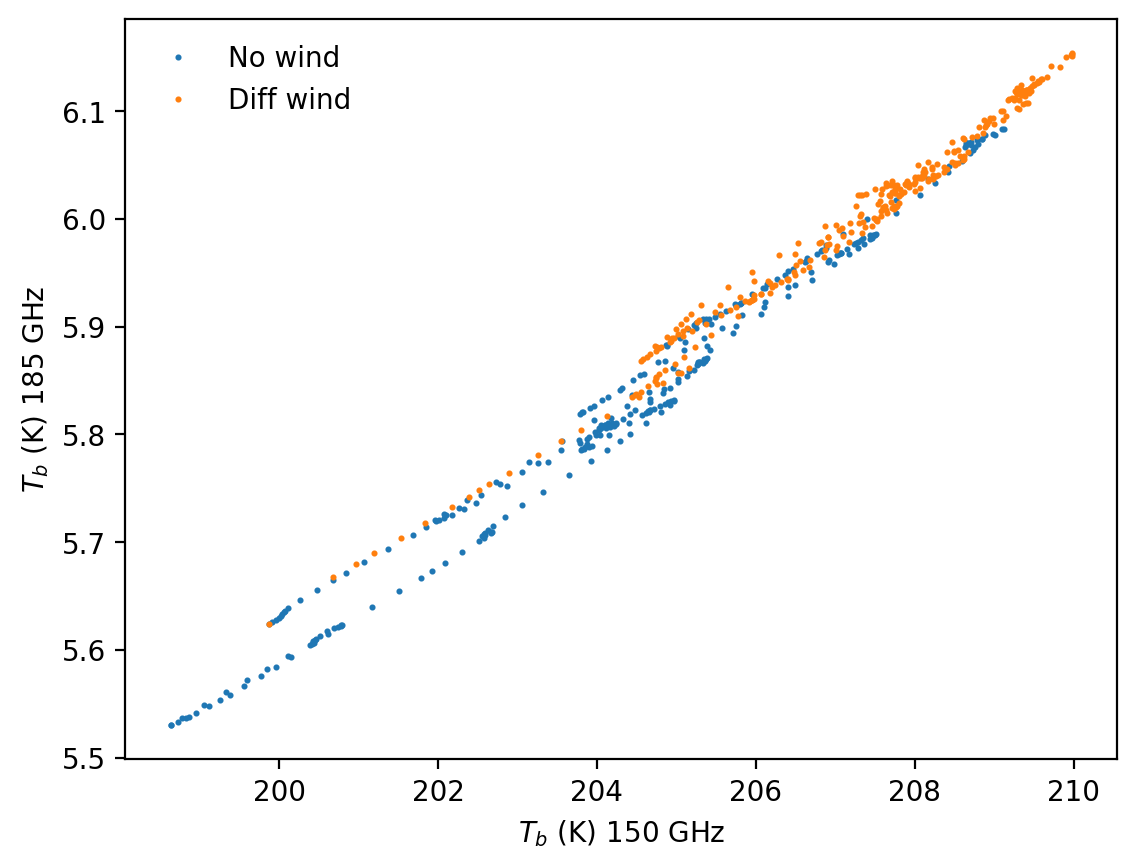

In [39]:
plt.figure(dpi=200)
plt.plot(timesamples, T_atm[:,0],   '-', lw=0.6, label=f'No wind {freqs_GHz[0]}')
plt.plot(timesamples, T_atm_w[:,0], '-', lw=0.6, label=f'Diff wind {freqs_GHz[0]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$T_b$ (K)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(timesamples, T_atm[:,1],   '-', lw=0.6, label=f'No wind {freqs_GHz[1]}')
plt.plot(timesamples, T_atm_w[:,1], '-', lw=0.6, label=f'Diff wind {freqs_GHz[1]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$T_b$ (K)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(timesamples, T_atm[:,0] - T_atm[:,0].mean(),   '-', lw=0.6, label=f'No wind {freqs_GHz[0]}')
plt.plot(timesamples, T_atm_w[:,0] - T_atm_w[:,0].mean(), '-', lw=0.6, label=f'Diff wind {freqs_GHz[0]}')
plt.plot(timesamples, T_atm[:,1] - T_atm[:,1].mean(),   '-', lw=0.6, label=f'No wind {freqs_GHz[1]}')
plt.plot(timesamples, T_atm_w[:,1] - T_atm_w[:,1].mean(), '-', lw=0.6, label=f'Diff wind {freqs_GHz[1]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$T_b$ (K)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(T_atm[:,0],   T_atm[:,1],   'o', ms=1.2, label=f'No wind')
plt.plot(T_atm_w[:,0], T_atm_w[:,1], 'o', ms=1.2, label=f'Diff wind')
plt.xlabel(r"$T_b$ (K) 150 GHz")
plt.ylabel(r"$T_b$ (K) 185 GHz")
plt.legend(frameon=False)
plt.show()
plt.close()

In [17]:
# ==============================================================================
# ITU-R P.676 Table 1: Oxygen Spectroscopic Data
# ==============================================================================
O2_f0 = jnp.array([50.474214, 50.987745, 51.50336, 52.021429, 52.542418, 53.066934, 53.595775, 54.130025, 54.67118, 55.221384, 55.783815, 56.264774, 56.363399, 56.968211, 57.612486, 58.323877, 58.446588, 59.164204, 59.590983, 60.306056, 60.434778, 61.150562, 61.800158, 62.41122, 62.486253, 62.997984, 63.568526, 64.127775, 64.67891, 65.224078, 65.764779, 66.302096, 66.836834, 67.369601, 67.900868, 68.431006, 68.960312, 118.750334, 368.498246, 424.76302, 487.249273, 715.392902, 773.83949, 834.145546])
O2_a1 = jnp.array([0.975, 2.529, 6.193, 14.32, 31.24, 64.29, 124.6, 227.3, 389.7, 627.1, 945.3, 543.4, 1331.8, 1746.6, 2120.1, 2363.7, 1442.1, 2379.9, 2090.7, 2103.4, 2438.0, 2479.5, 2275.9, 1915.4, 1503.0, 1490.2, 1078.0, 728.7, 461.3, 274.0, 153.0, 80.4, 39.8, 18.56, 8.172, 3.397, 1.334, 940.3, 67.4, 637.7, 237.4, 98.1, 572.3, 183.1])
O2_a2 = jnp.array([9.651, 8.653, 7.709, 6.819, 5.983, 5.201, 4.474, 3.8, 3.182, 2.618, 2.109, 0.014, 1.654, 1.255, 0.91, 0.621, 0.083, 0.387, 0.207, 0.207, 0.386, 0.621, 0.91, 1.255, 0.083, 1.654, 2.108, 2.617, 3.181, 3.8, 4.473, 5.2, 5.982, 6.818, 7.708, 8.652, 9.65, 0.01, 0.048, 0.044, 0.049, 0.145, 0.141, 0.145])
O2_a3 = jnp.array([6.69, 7.17, 7.64, 8.11, 8.58, 9.06, 9.55, 9.96, 10.37, 10.89, 11.34, 17.03, 11.89, 12.23, 12.62, 12.95, 14.91, 13.53, 14.08, 14.15, 13.39, 12.92, 12.63, 12.17, 15.13, 11.74, 11.34, 10.88, 10.38, 9.96, 9.55, 9.06, 8.58, 8.11, 7.64, 7.17, 6.69, 16.64, 16.4, 16.4, 16.0, 16.0, 16.2, 14.7])
O2_a4 = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
O2_a5 = jnp.array([2.566, 2.246, 1.947, 1.667, 1.388, 1.349, 2.227, 3.17, 3.558, 2.56, -1.172, 3.525, -2.378, -3.545, -5.416, -1.932, 6.768, -6.561, 6.957, -6.395, 6.342, 1.014, 5.014, 3.029, -4.499, 1.856, 0.658, -3.036, -3.968, -3.528, -2.548, -1.66, -1.68, -1.956, -2.216, -2.492, -2.773, -0.439, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
O2_a6 = jnp.array([6.85, 6.8, 6.729, 6.64, 6.526, 6.206, 5.085, 3.75, 2.654, 2.952, 6.135, -0.978, 6.547, 6.451, 6.056, 0.436, -1.273, 2.309, -0.776, 0.699, -2.825, -0.584, -6.619, -6.759, 0.844, -6.675, -6.139, -2.895, -2.59, -3.68, -5.002, -6.091, -6.393, -6.475, -6.545, -6.6, -6.65, 0.079, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

O2_DATA = {
    'f0': O2_f0, 'a1': O2_a1, 'a2': O2_a2, 
    'a3': O2_a3, 'a4': O2_a4, 'a5': O2_a5, 'a6': O2_a6
}

# ==============================================================================
# ITU-R P.676 Table 2: Water Vapor Spectroscopic Data
# ==============================================================================
H2O_f0 = jnp.array([22.23508, 67.80396, 119.99594, 183.310091, 321.225644, 325.152919, 336.222601, 380.197372, 390.134508, 437.346667, 439.150812, 443.018295, 448.001075, 470.888947, 474.689127, 488.491133, 503.568532, 504.482692, 547.67644, 552.02096, 556.936002, 620.700807, 645.866155, 658.00528, 752.033227, 841.053973, 859.962313, 899.306675, 902.616173, 906.207325, 916.171582, 923.118427, 970.315022, 987.926764, 1780.0])
H2O_b1 = jnp.array([0.113, 0.0012, 0.0008, 2.42, 0.0483, 1.499, 0.0011, 11.52, 0.0046, 0.065, 0.9218, 0.1976, 10.32, 0.3297, 1.262, 0.252, 0.039, 0.013, 9.701, 14.77, 487.4, 5.012, 0.0713, 0.3022, 239.6, 0.014, 0.1472, 0.0605, 0.0426, 0.1876, 8.34, 0.0869, 8.972, 132.1, 22300.0])
H2O_b2 = jnp.array([2.143, 8.735, 8.356, 0.668, 6.181, 1.54, 9.829, 1.048, 7.35, 5.05, 3.596, 5.05, 1.405, 3.599, 2.381, 2.853, 6.733, 6.733, 0.114, 0.114, 0.159, 2.2, 8.58, 7.82, 0.396, 8.18, 7.989, 7.917, 8.432, 5.111, 1.442, 10.22, 1.92, 0.258, 0.952])
H2O_b3 = jnp.array([28.11, 28.58, 29.48, 30.5, 23.03, 27.83, 26.93, 28.73, 21.52, 18.45, 21.0, 18.6, 26.32, 21.52, 23.55, 26.02, 16.12, 16.12, 26.0, 26.0, 32.1, 24.38, 18.0, 32.1, 30.6, 15.9, 30.6, 29.85, 28.65, 24.08, 26.7, 29.0, 25.5, 29.85, 176.2])
H2O_b4 = jnp.array([0.69, 0.69, 0.7, 0.64, 0.67, 0.68, 0.69, 0.54, 0.63, 0.6, 0.63, 0.6, 0.66, 0.66, 0.65, 0.69, 0.61, 0.61, 0.7, 0.7, 0.69, 0.71, 0.6, 0.69, 0.68, 0.33, 0.68, 0.68, 0.7, 0.7, 0.7, 0.7, 0.64, 0.68, 0.5])
H2O_b5 = jnp.array([4.8, 4.93, 4.78, 5.3, 4.69, 4.85, 4.74, 5.38, 4.81, 4.23, 4.29, 4.23, 4.84, 4.57, 4.65, 5.04, 3.98, 4.01, 4.5, 4.5, 4.11, 4.68, 4.0, 4.14, 4.09, 5.76, 4.09, 4.53, 5.1, 4.7, 4.78, 5.0, 4.94, 4.55, 30.5])
H2O_b6 = jnp.array([1.0, 0.82, 0.79, 0.85, 0.54, 0.74, 0.61, 0.89, 0.55, 0.48, 0.52, 0.5, 0.67, 0.65, 0.64, 0.72, 0.43, 0.45, 1.0, 1.0, 1.0, 0.68, 0.5, 1.0, 0.84, 0.45, 0.84, 0.9, 0.95, 0.53, 0.78, 0.8, 0.67, 0.9, 5.0])

H2O_DATA = {
    'f0': H2O_f0, 'b1': H2O_b1, 'b2': H2O_b2, 
    'b3': H2O_b3, 'b4': H2O_b4, 'b5': H2O_b5, 'b6': H2O_b6
}

from scipy import constants

def B_nu_T(nu_in_GHz, T_bb):
    """
    B_nu_T is the Planck distribution function, defined as: 
    .. math::
        B(\\nu, T) = \\frac{2 h \\nu^3}{c^2} \\frac{1}{e^{x} - 1},
    with 
    .. math::
        x = \\frac{h \\nu}{k_B T}.
    
    It returns the Planck function values for nu (can be vectorized) 
    for a given blackbody temperature.

    Parameters
    ----------
    nu_in_GHz : float or numpy ndarray
        Frequency in GHz at which we want the value of the Planck function.
    T_planck : float, optional
        Temperature of the Planck distribution in Kelvin.
        Default value set to the CMB monopole temperature of 2.7255 K.

    Returns
    -------
    float or numpy ndarray
        A float value (or ndarray) for the value(s) of the Planck distribution.

    """

    nu_in_Hz = nu_in_GHz * constants.giga
    x = constants.h * nu_in_Hz / constants.k_B / T_bb
    prefactor = 2. * constants.h * nu_in_Hz**3. / constants.c**2.

    return prefactor / (jnp.exp(x) - 1.)

def intensitySI_to_Tb(I_nu, freq_in_GHz):
    return constants.c**2 / 2. / constants.k_B / (freq_in_GHz * constants.giga)**2. * I_nu

In [ ]:
#let's do our own emission version using the same parameters
from atmo3 import constants
def compute_attenuation_point_v(T, P, e, freqs_GHz, o2_data, h2o_data):
    """
    Computes the specific attenuation for a single spatial point over multiple frequencies.
    Input scalars: T (Kelvin), P (hPa, dry air pressure), e (hPa, water vapor pressure).
    Input vector: freqs_GHz (shape: Nf,)
    Returns: gamma_dry, gamma_wet (both shape: Nf,)
    """
    # Expand freqs for matrix broadcasting against spectral lines
    # f shape: (Nf, 1)
    f = freqs_GHz[:, None] 
    
    # Temperature parameter
    theta = 300.0 / T
    
    # --- Oxygen Calculation ---
    f_o2 = o2_data['f0'][None, :] # Shape: (1, N_o2_lines), frequency of each oxygen line
    
    # Line strength
    S_o2 = o2_data['a1'] * 1e-7 * P * (theta**3) * jnp.exp(o2_data['a2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Zeeman broadening
    df_o2 = o2_data['a3'] * 1e-4 * (P * (theta**(0.8 - o2_data['a4'])) + 1.1 * e * theta) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_o2 = jnp.sqrt(df_o2**2 + 2.25e-6) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Interference factor
    delta_o2 = (o2_data['a5'] + o2_data['a6'] * theta) * 1e-4 * (P + e) * (theta**0.8) # Eq (7) from ITU-R P.676-13 Annex 1
    
    # Line shape (Van Vleck-Weisskopf)
    num1 = df_o2 - delta_o2 * (f_o2 - f)
    den1 = (f_o2 - f)**2 + df_o2**2
    num2 = df_o2 - delta_o2 * (f_o2 + f)
    den2 = (f_o2 + f)**2 + df_o2**2
    F_o2 = (f / f_o2) * ((num1 / den1) + (num2 / den2)) # Eq (5) from ITU-R P.676-13 Annex 1
    
    # Sum over all lines (axis 1 collapses the lines, leaving shape Nf)
    N_pp_o2_lines = jnp.sum(S_o2 * F_o2, axis=1) # You sum over the lines
    
    # Dry Continuum (Debye spectrum + nitrogen attenuation)
    d = 5.6e-4 * (P + e) * (theta**0.8) #eq (9) from ITU-R P.676-13 Annex 1
    term1 = 6.14e-5 / (d * (1 + (freqs_GHz / d)**2))
    term2 = (1.4e-12 * P * (theta**1.5)) / (1 + 1.9e-5 * (freqs_GHz**1.5))
    N_pp_D = freqs_GHz * P * (theta**2) * (term1 + term2) # Eq (8) from ITU-R P.676-13 Annex 1
    
    gamma_dry = 0.1820 * freqs_GHz * (N_pp_o2_lines + N_pp_D) # Eq (1) and (2a) from ITU-R P.676-13 Annex 1


    # --- Water Vapor Calculation ---
    f_h2o = h2o_data['f0'][None, :] #frequency of each water vapor line, shape: (1, N_h2o_lines)
    
    # Line strength
    S_h2o = h2o_data['b1'] * 1e-1 * e * (theta**3.5) * jnp.exp(h2o_data['b2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Doppler broadening
    df_h2o = h2o_data['b3'] * 1e-4 * (P * (theta**h2o_data['b4']) + h2o_data['b5'] * e * (theta**h2o_data['b6'])) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_h2o = 0.535 * df_h2o + jnp.sqrt(0.217 * (df_h2o**2) + (2.1316e-12 * (f_h2o**2)) / theta) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Line shape (interference factor delta is 0 for H2O)
    num1_w = df_h2o
    den1_w = (f_h2o - f)**2 + df_h2o**2
    num2_w = df_h2o
    den2_w = (f_h2o + f)**2 + df_h2o**2
    F_h2o = (f / f_h2o) * ((num1_w / den1_w) + (num2_w / den2_w)) # Eq (5) from ITU-R P.676-13 Annex 1, but with delt_H2O=0 for water vapor lines
    
    # Sum over all water vapor lines
    N_pp_h2o = jnp.sum(S_h2o * F_h2o, axis=1)
    
    gamma_wet = 0.1820 * freqs_GHz * N_pp_h2o # Eq (1) and (2b) from ITU-R P.676-13 Annex 1
    
    return gamma_dry, gamma_wet


@jax.jit
def compute_attenuation_los_v(T_los, P_los, P_water_los, freqs_in_GHz, o2_data, h2o_data):
    # T_los, P_los, P_water_los have shape (n_scans, n_los)
    # Inner vmap: outputs (Nf, n_los) by setting out_axes=-1
    # Outer vmap: outputs (n_scans, Nf, n_los) by setting out_axes=0
    
    gamma_dry_grid, gamma_wet_grid = jax.vmap(
        jax.vmap(
            lambda t, p, p_water: compute_attenuation_point_v(t, p, p_water, freqs_in_GHz, o2_data, h2o_data),
            in_axes=(0, 0, 0),
            out_axes=-1
        ),
        in_axes=(0, 0, 0),
        out_axes=0
    )(T_los, P_los, P_water_los)
    
    # Return in the standard order (dry, wet) or however your RT integration expects it!
    return gamma_dry_grid, gamma_wet_grid

@jax.jit
def get_emission_v(T_los, P_los, p_water_los, ds, freqs_in_GHz):
    #gamma_O2, gamma_H2O = compute_attenuation_los_v(T_los, P_los, rho_los, freqs_in_GHz, O2_DATA, H2O_DATA)
    gamma_O2, gamma_H2O = compute_attenuation_los_v(T_los, P_los, p_water_los, freqs_in_GHz, constants.O2_DATA, constants.H2O_DATA)
    
    # ds needs a dummy frequency dimension to broadcast against (n_scans, Nf, n_los)
    #A_nu = (gamma_H2O + gamma_O2) * ds[:, None, :]* jnp.log(10.)/10 / 1e3     # Assuming ds is provided in m, we convert from dB/km to Np/m by multiplying by log(10)/10 and dividing by 1e3.
    A_nu = (gamma_H2O + gamma_O2) * ds[:, None, :] / 1e3     # Assuming ds is provided in m, we convert from dB/km to dB/m by dividing by 1e3.


    # Accumulate attenuation looking inward from the first element
    # Shifted to avoid applying the current shell's attenuation to its own lower boundary
    Alower_nu = jnp.concatenate([jnp.zeros_like(A_nu[:, :, :1]), jnp.cumsum(A_nu[:, :, :-1], axis=2)], axis=2)
    
    # B_nu_T inputs broadcast to (n_scans, Nf, n_los)
    B_nu = B_nu_T(freqs_in_GHz[None, :, None], T_los[:, None, :])
    
    #return jnp.sum(B_nu * (1. - jnp.exp(-A_nu)) * jnp.exp(-Alower_nu), axis=2)
    return jnp.sum(B_nu * (1. - 10.**(-A_nu / 10.)) * 10.**(-Alower_nu / 10.), axis=2)

In [29]:
from atmo3 import constants

pressure_los_hPa = pressure_los / 100.0 
pressure_los_w_hPa = pressure_los_w / 100.0

P_water_los_hPa = water_vapor_los * constants.R_water_vapor * temperature_los / 100.0  # Convert from kg/m³ to hPa using ideal gas law: P = ρ R T
P_water_los_w_hPa = water_vapor_los_w * constants.R_water_vapor * temperature_los_w / 100.0  # Convert from kg/m³ to hPa using ideal gas law: P = ρ R T

In [33]:
B_nu_los = get_emission_v(temperature_los, pressure_los_hPa, P_water_los_hPa, jnp.diff(obs.los_obj[:,:,3], axis=1, prepend=0), freqs_GHz)
T_b_los = intensitySI_to_Tb(B_nu_los, freqs_GHz)

B_nu_los_w = get_emission_v(temperature_los_w, pressure_los_w_hPa, P_water_los_w_hPa, jnp.diff(obs_w.los_obj[:,:,3], axis=1, prepend=0), freqs_GHz)
T_b_los_w = intensitySI_to_Tb(B_nu_los_w, freqs_GHz)

In [23]:
print(T_b_los.shape)

(300, 2)


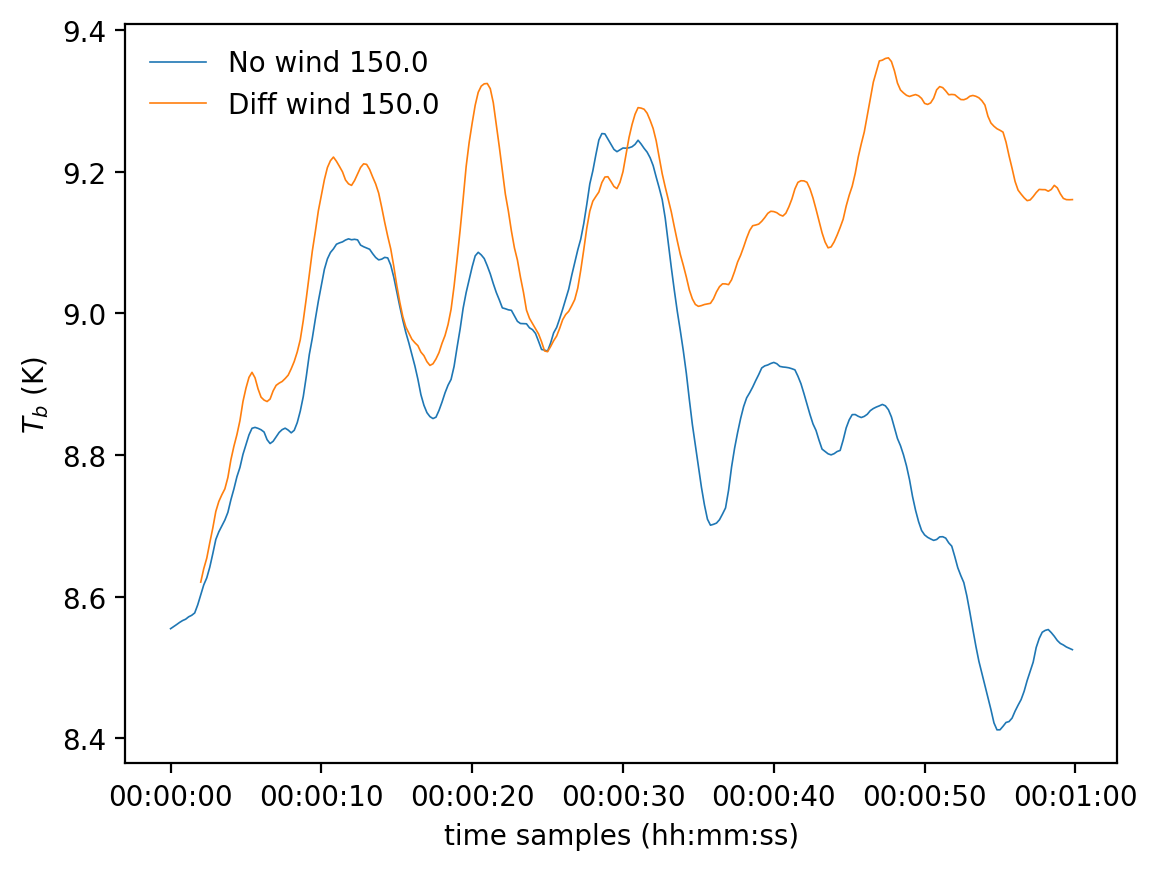

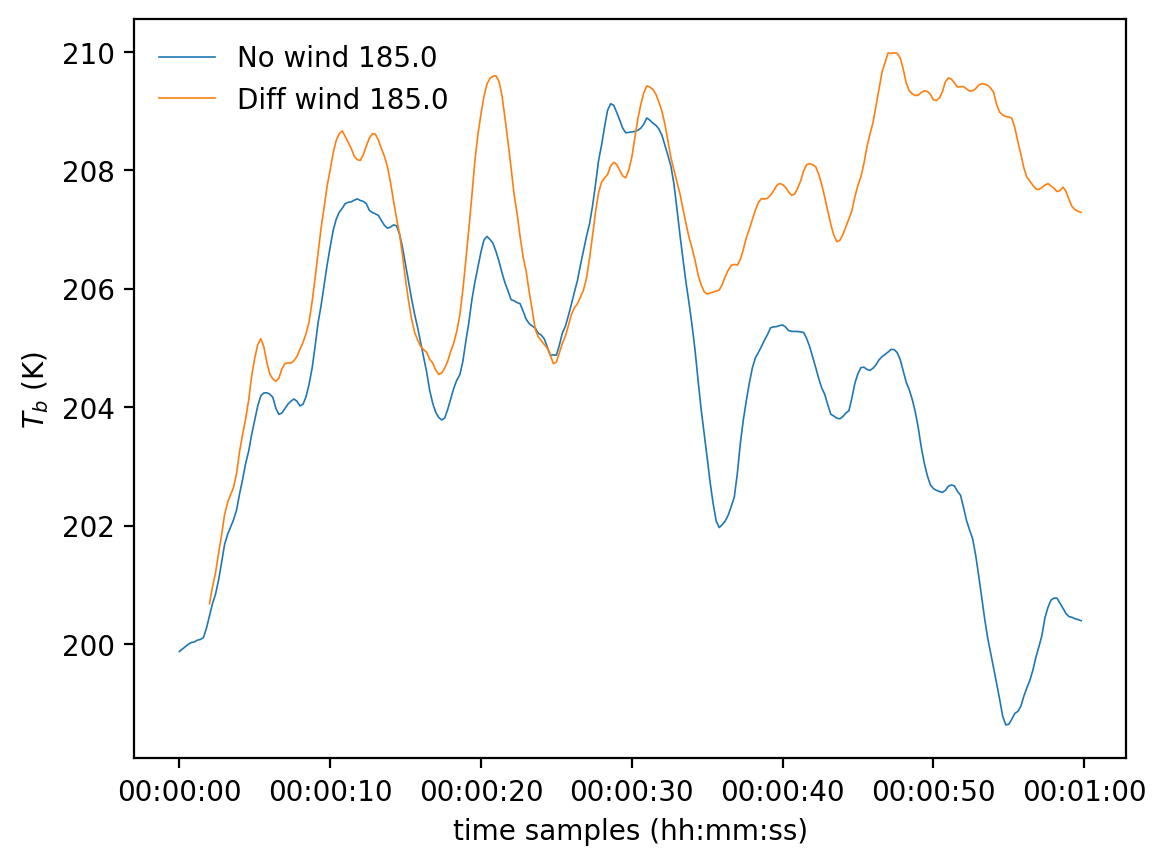

In [34]:
plt.figure(dpi=200)
plt.plot(timesamples, T_b_los[:,0],   '-', lw=0.6, label=f'No wind {freqs_GHz[0]}')
plt.plot(timesamples, T_b_los_w[:,0], '-', lw=0.6, label=f'Diff wind {freqs_GHz[0]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$T_b$ (K)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(timesamples, T_b_los[:,1],   '-', lw=0.6, label=f'No wind {freqs_GHz[1]}')
plt.plot(timesamples, T_b_los_w[:,1], '-', lw=0.6, label=f'Diff wind {freqs_GHz[1]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$T_b$ (K)")
plt.legend(frameon=False)
plt.show()
plt.close()